# Chess Data — EDA

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = 'output'  # change if needed

games   = pd.read_csv(f'{OUTPUT_DIR}/games.csv')
moves   = pd.read_csv(f'{OUTPUT_DIR}/moves.csv')
summary = pd.read_csv(f'{OUTPUT_DIR}/summary.csv')

# numeric coercions
for col in ['target_elo', 'opponent_elo', 'white_elo', 'black_elo']:
    games[col] = pd.to_numeric(games[col], errors='coerce')
for col in ['mean_cp_loss', 'median_cp_loss', 'p90_cp_loss',
            'opening_mean_cp_loss', 'middlegame_mean_cp_loss', 'endgame_mean_cp_loss']:
    summary[col] = pd.to_numeric(summary[col], errors='coerce')

# target moves only
tm = moves[(moves['is_target_move'] == True) & moves['cp_loss'].notna()].copy()
tm['cp_loss'] = pd.to_numeric(tm['cp_loss'], errors='coerce')
tm = tm.dropna(subset=['cp_loss'])
tm['cp_loss_capped'] = tm['cp_loss'].clip(0, 500)

QUALITY_ORDER = ['Good', 'Inaccuracy', 'Mistake', 'Blunder']
PHASE_ORDER   = ['opening', 'middlegame', 'endgame']
PIECE_ORDER   = ['Pawn', 'Knight', 'Bishop', 'Rook', 'Queen', 'King']

print(f'Games    : {len(games):,}')
print(f'Players  : {games["target_name"].nunique():,}')
print(f'Plies    : {len(moves):,}  ->  target moves: {len(tm):,}')
print(f'Speeds   : {games["speed"].value_counts().to_dict()}')

Games    : 25,848
Players  : 941
Plies    : 1,628,149  ->  target moves: 814,042
Speeds   : {'bullet': 13486, 'blitz': 8572, 'ultraBullet': 2035, 'rapid': 1522, 'classical': 216, 'correspondence': 17}


## 1 — Dataset basics

In [11]:
print('games.csv')
display(games.describe(include='all').T)
print('\nMissing values:')
display(games.isnull().sum().rename('missing').to_frame())

games.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
game_id,25848,25330,IzHU0BhL,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_utc,25848,24641,2026-03-20T12:44:11.794000+00:00,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_control,25831,101,60+0,11087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speed,25848,6,bullet,13486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rated,25848,1,True,25848,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,25848,6,outoftime,11157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ply_count,25848.0,NaN,NaN,NaN,64.292711,21.776375,5.0,49.0,61.0,76.0,260.0
white_name,25848,11335,valera69,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
black_name,25848,11303,JayEdgarMaddox,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
white_elo,25848.0,NaN,NaN,NaN,1692.565073,339.935099,402.0,1459.0,1712.0,1941.0,3006.0



Missing values:


,missing
game_id,0
date_utc,0
time_control,17
speed,0
rated,0
status,0
ply_count,0
white_name,0
black_name,0
white_elo,0


In [12]:
print('moves.csv (target moves only)')
display(tm[['cp_loss_capped','is_capture','is_check','is_castle','is_promotion']].describe().T)
print('\nMissing values (moves.csv):')
display(moves.isnull().sum()[moves.isnull().sum() > 0].rename('missing').to_frame())

moves.csv (target moves only)


,count,mean,std,min,25%,50%,75%,max
cp_loss_capped,814042.0,2.903993,20.255848,0.0,0.0,0.0,0.0,500.0



Missing values (moves.csv):


,missing
promotion_piece,1625391
best_move_san,1265904
best_move_uci,1265904
cp_loss,814107
move_quality,814107
clock_before_cs,895
clock_after_cs,895
time_spent_cs,895


In [13]:
print('summary.csv')
display(summary.describe().T)

summary.csv


,count,mean,std,min,25%,50%,75%,max
target_elo,25848.0,1688.060740,316.987789,472.00,1465.0000,1716.00,1939.0000,2600.00
opponent_elo,25848.0,1701.142835,362.701532,402.00,1456.0000,1716.00,1949.0000,3028.00
target_score,25848.0,0.496402,0.496386,0.00,0.0000,0.50,1.0000,1.00
total_moves,25848.0,31.493423,10.906690,2.00,24.0000,30.00,38.0000,130.00
mean_cp_loss,25848.0,-1207.087067,152578.364513,-24530708.64,-405.6875,-89.11,-45.5400,496.60
median_cp_loss,25848.0,-22.633124,19.687351,-590.00,-29.0000,-17.50,-10.5000,7.00
p90_cp_loss,25848.0,6.749110,14.294546,-57.00,2.0000,6.00,10.0000,1683.00
good_moves,25848.0,31.294607,10.715368,2.00,24.0000,30.00,37.0000,130.00
inaccuracies,25848.0,0.116295,0.360464,0.00,0.0000,0.00,0.0000,4.00
mistakes,25848.0,0.030795,0.185926,0.00,0.0000,0.00,0.0000,5.00


## 2 — Games overview

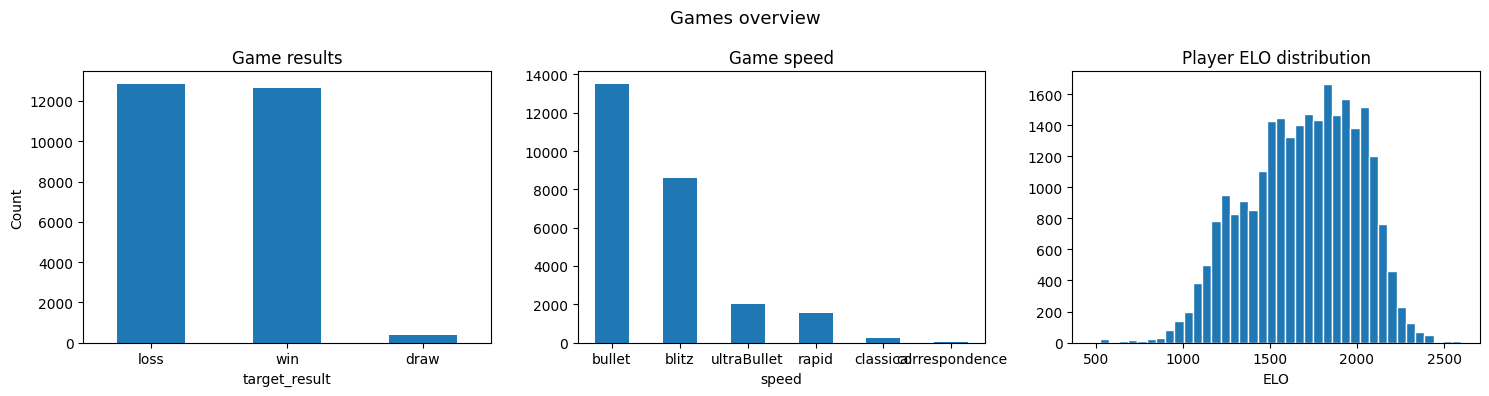

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Games overview', fontsize=13)

games['target_result'].value_counts().plot.bar(ax=axes[0], rot=0)
axes[0].set_title('Game results')
axes[0].set_ylabel('Count')

games['speed'].value_counts().plot.bar(ax=axes[1], rot=0)
axes[1].set_title('Game speed')

axes[2].hist(games['target_elo'].dropna(), bins=40, edgecolor='white')
axes[2].set_title('Player ELO distribution')
axes[2].set_xlabel('ELO')

plt.tight_layout()
plt.show()

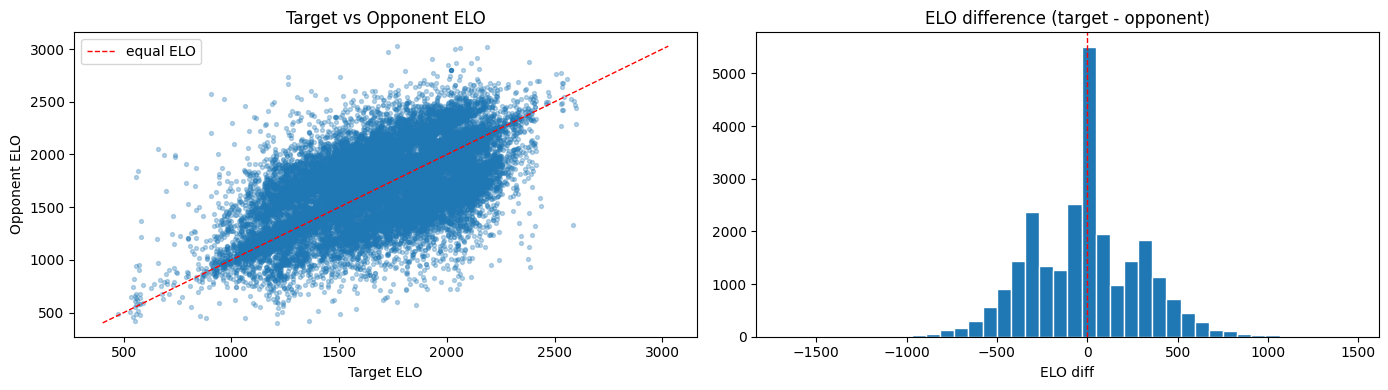

Mean ELO diff              : -13.1
% games vs stronger player : 52.2%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(games['target_elo'], games['opponent_elo'], alpha=0.3, s=8)
lims = [games[['target_elo','opponent_elo']].min().min(),
        games[['target_elo','opponent_elo']].max().max()]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='equal ELO')
axes[0].set_xlabel('Target ELO')
axes[0].set_ylabel('Opponent ELO')
axes[0].set_title('Target vs Opponent ELO')
axes[0].legend()

elo_diff = games['target_elo'] - games['opponent_elo']
axes[1].hist(elo_diff.dropna(), bins=40, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('ELO difference (target - opponent)')
axes[1].set_xlabel('ELO diff')

plt.tight_layout()
plt.show()
print(f'Mean ELO diff              : {elo_diff.mean():.1f}')
print(f'% games vs stronger player : {(elo_diff < 0).mean()*100:.1f}%')

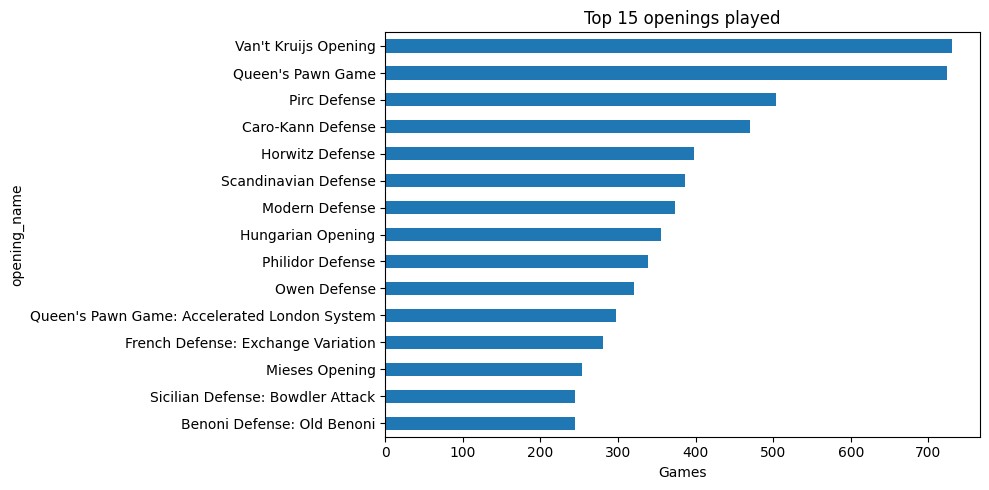

In [16]:
games['opening_name'].value_counts().head(15).plot.barh(figsize=(10, 5))
plt.title('Top 15 openings played')
plt.xlabel('Games')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3 — Move quality

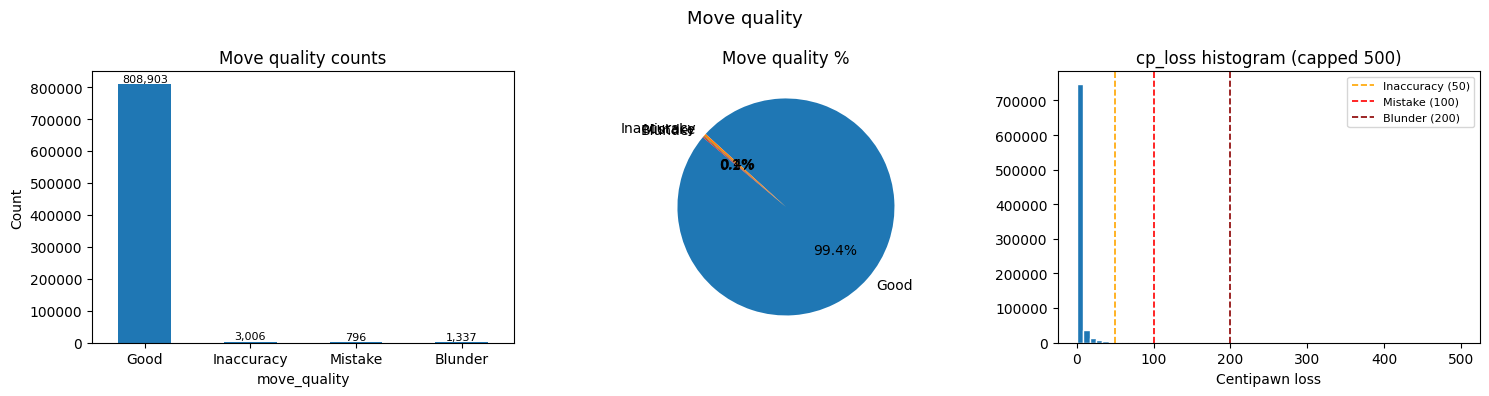

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Move quality', fontsize=13)

counts = tm['move_quality'].value_counts().reindex(QUALITY_ORDER, fill_value=0)
counts.plot.bar(ax=axes[0], rot=0)
axes[0].set_title('Move quality counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + counts.max()*0.01, f'{v:,}', ha='center', fontsize=8)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Move quality %')

axes[2].hist(tm['cp_loss_capped'], bins=60, edgecolor='white')
for thresh, label, color in [(50,'Inaccuracy','orange'),(100,'Mistake','red'),(200,'Blunder','darkred')]:
    axes[2].axvline(thresh, color=color, linestyle='--', linewidth=1.2, label=f'{label} ({thresh})')
axes[2].set_title('cp_loss histogram (capped 500)')
axes[2].set_xlabel('Centipawn loss')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Weakness analysis

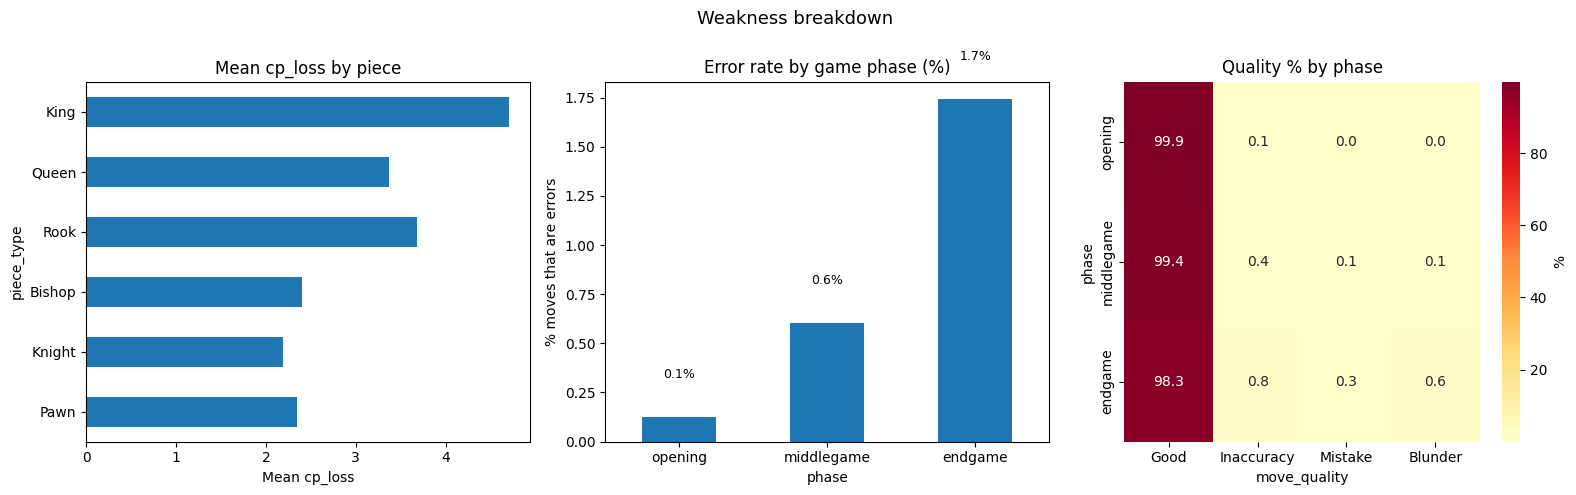

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Weakness breakdown', fontsize=13)

piece_mean = tm.groupby('piece_type')['cp_loss_capped'].mean()\
               .reindex([p for p in PIECE_ORDER if p in tm['piece_type'].unique()])
piece_mean.plot.barh(ax=axes[0])
axes[0].set_title('Mean cp_loss by piece')
axes[0].set_xlabel('Mean cp_loss')

phase_total  = tm['phase'].value_counts().reindex(PHASE_ORDER, fill_value=0)
phase_errors = tm[tm['move_quality'] != 'Good']['phase'].value_counts().reindex(PHASE_ORDER, fill_value=0)
error_rate   = (phase_errors / phase_total * 100).fillna(0)
error_rate.plot.bar(ax=axes[1], rot=0)
axes[1].set_title('Error rate by game phase (%)')
axes[1].set_ylabel('% moves that are errors')
for i, v in enumerate(error_rate.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

heat = tm.groupby(['phase','move_quality']).size().unstack(fill_value=0)
heat = heat.reindex(PHASE_ORDER).reindex(columns=QUALITY_ORDER, fill_value=0)
heat_pct = heat.div(heat.sum(axis=1), axis=0) * 100
sns.heatmap(heat_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[2], cbar_kws={'label': '%'})
axes[2].set_title('Quality % by phase')

plt.tight_layout()
plt.show()

Blunder count — piece x phase:


phase,opening,middlegame,endgame
piece_type,,,
Bishop,4,33,43
King,0,106,387
Knight,2,48,21
Pawn,5,72,196
Queen,3,185,0
Rook,0,87,145


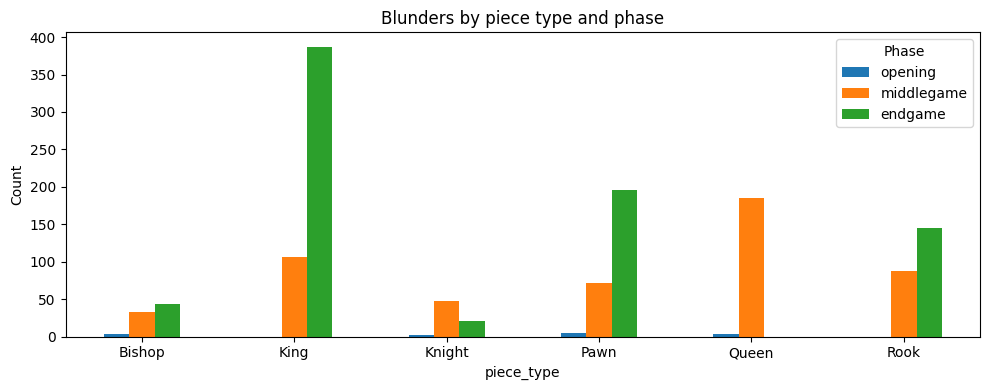

In [19]:
blunders = tm[tm['move_quality'] == 'Blunder']
ct = pd.crosstab(blunders['piece_type'], blunders['phase'])
ct = ct.reindex(columns=[p for p in PHASE_ORDER if p in ct.columns])
print('Blunder count — piece x phase:')
display(ct)

ct.plot.bar(figsize=(10, 4), rot=0)
plt.title('Blunders by piece type and phase')
plt.ylabel('Count')
plt.legend(title='Phase')
plt.tight_layout()
plt.show()

Tactical move counts:
  Captures    : 199,452  (24.50%)
  Checks      : 54,105  (6.65%)
  Castles     : 20,336  (2.50%)
  Promotions  : 1,277  (0.16%)


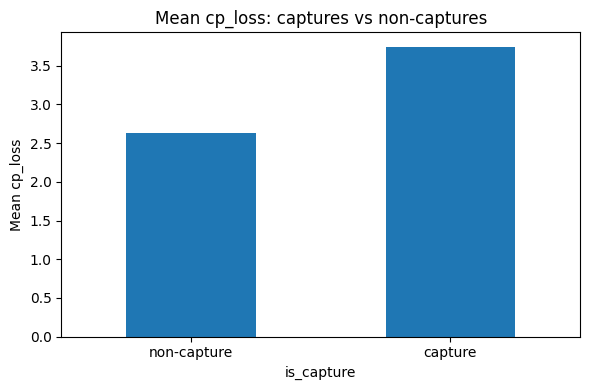

In [20]:
flags = {
    'Captures'  : tm['is_capture'].sum(),
    'Checks'    : tm['is_check'].sum(),
    'Castles'   : tm['is_castle'].sum(),
    'Promotions': tm['is_promotion'].sum(),
}
print('Tactical move counts:')
for k, v in flags.items():
    print(f'  {k:<12}: {v:,}  ({v/len(tm)*100:.2f}%)')

tm.groupby('is_capture')['cp_loss_capped'].mean()\
  .rename({True:'capture', False:'non-capture'})\
  .plot.bar(rot=0, figsize=(6, 4))
plt.title('Mean cp_loss: captures vs non-captures')
plt.ylabel('Mean cp_loss')
plt.tight_layout()
plt.show()

## 5 — Rating vs quality

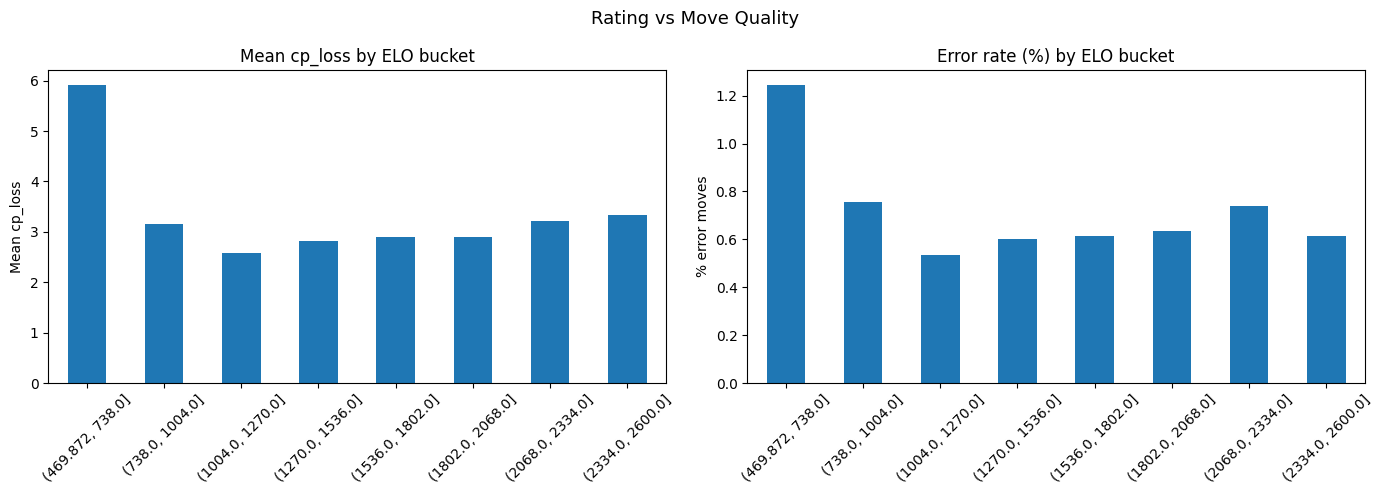

Pearson correlation (ELO vs cp_loss): 0.0055


In [21]:
elo_map = games.set_index('game_id')[['target_elo']].dropna()
tm_elo  = tm.join(elo_map, on='game_id').dropna(subset=['target_elo'])
tm_elo['target_elo'] = pd.to_numeric(tm_elo['target_elo'], errors='coerce')
tm_elo  = tm_elo.dropna(subset=['target_elo'])
tm_elo['elo_bucket'] = pd.cut(tm_elo['target_elo'], bins=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating vs Move Quality', fontsize=13)

tm_elo.groupby('elo_bucket')['cp_loss_capped'].mean().plot.bar(ax=axes[0], rot=45)
axes[0].set_title('Mean cp_loss by ELO bucket')
axes[0].set_ylabel('Mean cp_loss')
axes[0].set_xlabel('')

tm_elo.groupby('elo_bucket').apply(
    lambda x: (x['move_quality'] != 'Good').mean() * 100
).plot.bar(ax=axes[1], rot=45)
axes[1].set_title('Error rate (%) by ELO bucket')
axes[1].set_ylabel('% error moves')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

corr = tm_elo['target_elo'].corr(tm_elo['cp_loss_capped'])
print(f'Pearson correlation (ELO vs cp_loss): {corr:.4f}')

## 6 — Per-game summary stats

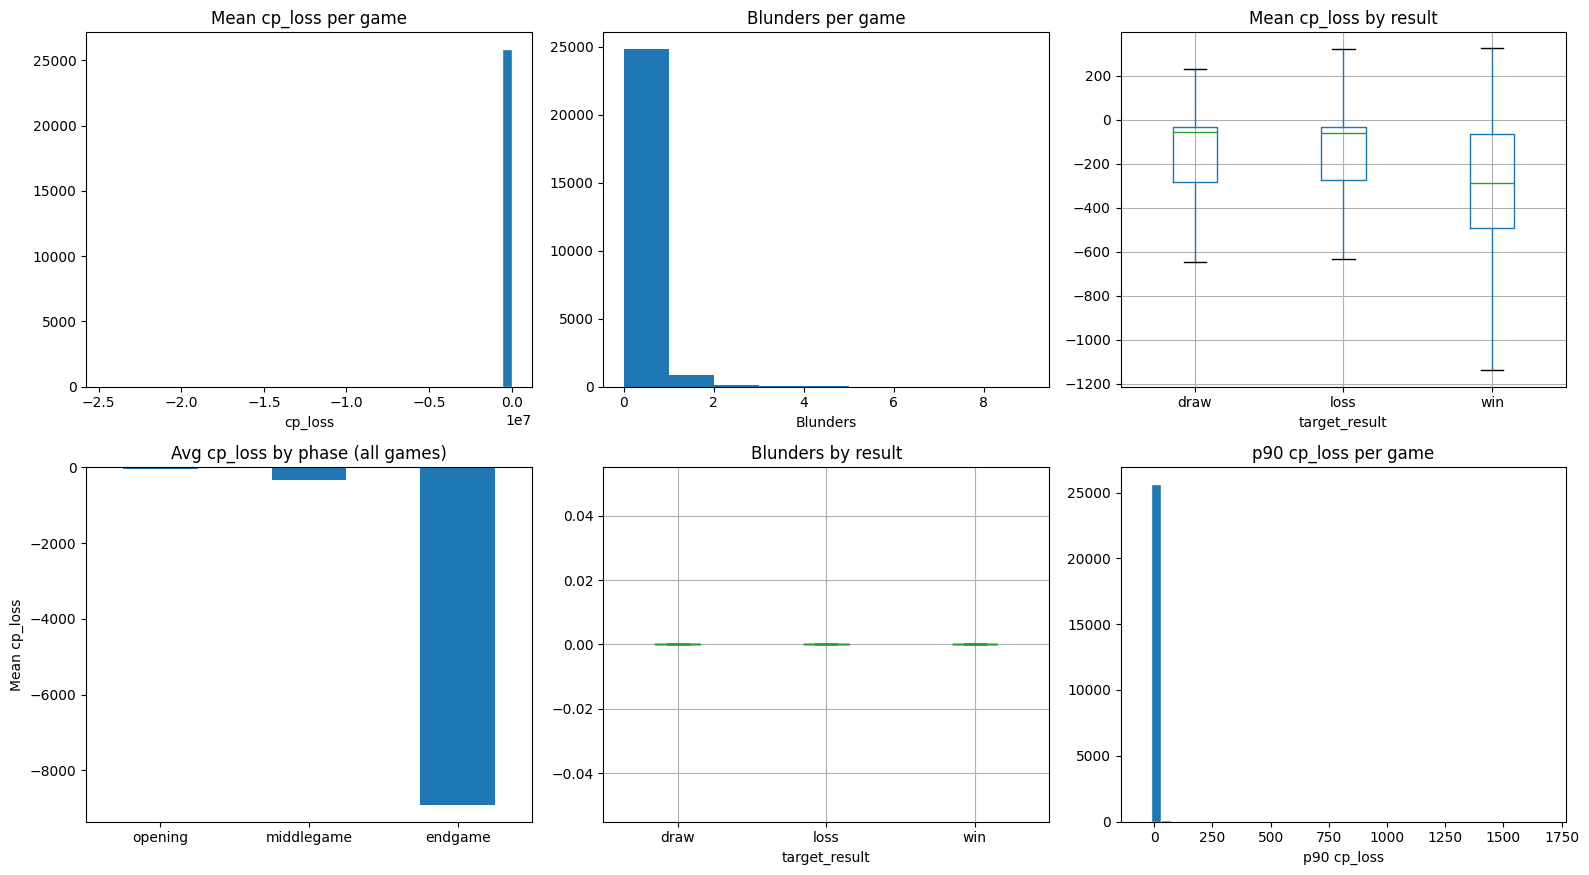

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Per-game summary stats', fontsize=13)

axes[0,0].hist(summary['mean_cp_loss'].dropna(), bins=40, edgecolor='white')
axes[0,0].set_title('Mean cp_loss per game')
axes[0,0].set_xlabel('cp_loss')

axes[0,1].hist(summary['blunders'].dropna(), bins=range(0, int(summary['blunders'].max())+2))
axes[0,1].set_title('Blunders per game')
axes[0,1].set_xlabel('Blunders')

summary.boxplot(column='mean_cp_loss', by='target_result', ax=axes[0,2], sym='')
plt.sca(axes[0,2]); plt.title('Mean cp_loss by result'); plt.suptitle('')

summary[['opening_mean_cp_loss','middlegame_mean_cp_loss','endgame_mean_cp_loss']]\
    .mean().rename({'opening_mean_cp_loss':'opening',
                    'middlegame_mean_cp_loss':'middlegame',
                    'endgame_mean_cp_loss':'endgame'})\
    .plot.bar(ax=axes[1,0], rot=0)
axes[1,0].set_title('Avg cp_loss by phase (all games)')
axes[1,0].set_ylabel('Mean cp_loss')

summary.boxplot(column='blunders', by='target_result', ax=axes[1,1], sym='')
plt.sca(axes[1,1]); plt.title('Blunders by result'); plt.suptitle('')

axes[1,2].hist(summary['p90_cp_loss'].dropna(), bins=40, edgecolor='white')
axes[1,2].set_title('p90 cp_loss per game')
axes[1,2].set_xlabel('p90 cp_loss')

plt.tight_layout()
plt.show()

## 7 — Correlation matrix

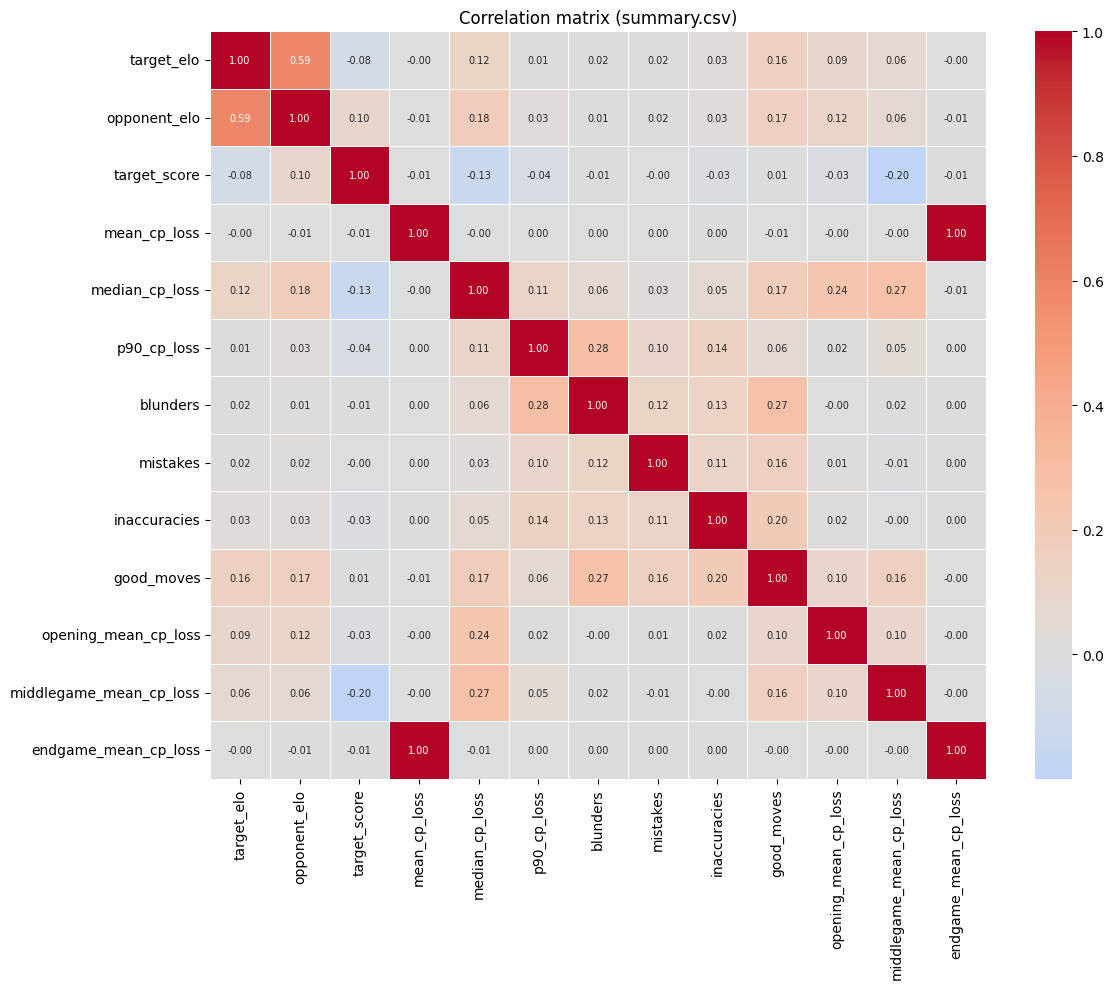

In [23]:
corr_cols = [
    'target_elo','opponent_elo','target_score',
    'mean_cp_loss','median_cp_loss','p90_cp_loss',
    'blunders','mistakes','inaccuracies','good_moves',
    'opening_mean_cp_loss','middlegame_mean_cp_loss','endgame_mean_cp_loss'
]
corr_df = summary[corr_cols].apply(pd.to_numeric, errors='coerce').corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation matrix (summary.csv)')
plt.tight_layout()
plt.show()

## 8 — Player analysis

In [ ]:
players = pd.read_csv(f"{OUTPUT_DIR}/players.csv")
players["elo"] = pd.to_numeric(players["elo"], errors="coerce")
players["blunder_rate"] = pd.to_numeric(players["blunder_rate"], errors="coerce")
players["mistake_rate"] = pd.to_numeric(players["mistake_rate"], errors="coerce")
players["inaccuracy_rate"] = pd.to_numeric(players["inaccuracy_rate"], errors="coerce")
players["win_rate"] = pd.to_numeric(players["win_rate"], errors="coerce")
players["mean_cp_loss"] = pd.to_numeric(players["mean_cp_loss"], errors="coerce")

print(f"Total players : {len(players):,}")
print(f"ELO buckets   : {players['elo_bucket'].value_counts().to_dict()}")
display(players.describe())

Total players : 941
ELO buckets   : {'1000-1400': 197, '1400-1600': 191, '1600-1800': 191, '1800-2000': 188, '2000-2200': 174}


,elo,games_collected,mean_cp_loss,median_cp_loss,blunder_rate,mistake_rate,inaccuracy_rate,avg_blunders_per_game,avg_mistakes_per_game,win_rate
count,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000
mean,1677.561105,27.468650,-1130.583560,-22.956748,0.001578,0.000930,0.003646,0.050553,0.029447,0.497949
std,321.252515,5.901886,26656.537611,8.185127,0.001891,0.001089,0.002694,0.061752,0.035989,0.156011
min,563.000000,1.000000,-817965.070000,-84.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1440.000000,28.000000,-307.090000,-26.000000,0.000000,0.000000,0.002100,0.000000,0.000000,0.400000
50%,1713.000000,30.000000,-252.810000,-21.470000,0.001100,0.001000,0.003300,0.030000,0.030000,0.500000
75%,1943.000000,30.000000,-200.980000,-17.810000,0.002300,0.001400,0.005000,0.070000,0.040000,0.600000
max,2396.000000,30.000000,-17.230000,-7.000000,0.014000,0.006200,0.045500,0.390000,0.200000,1.000000


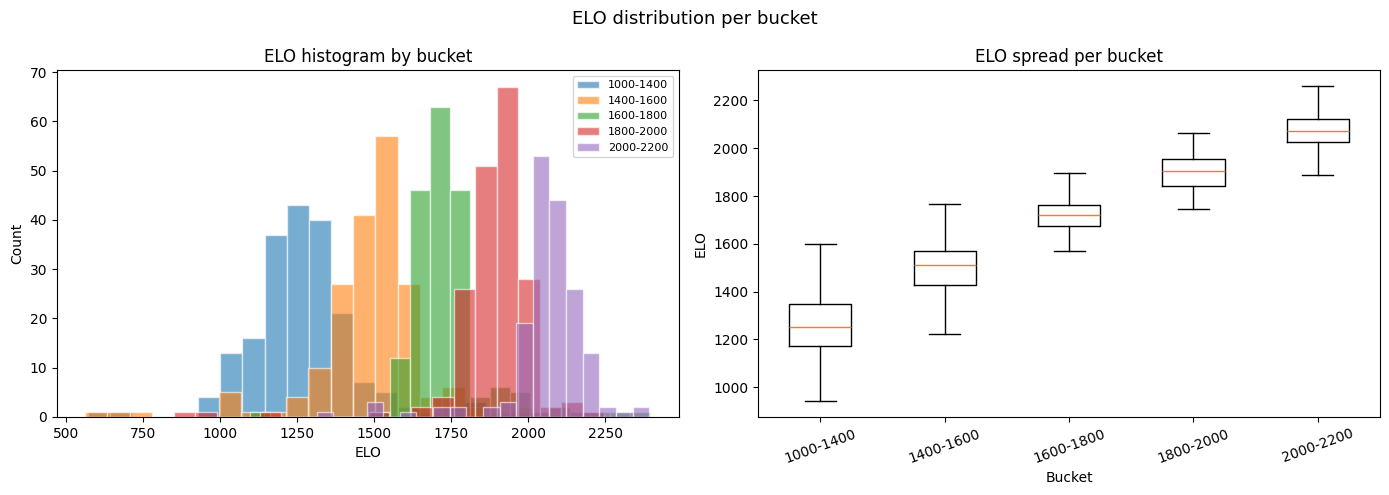

In [25]:
# 8a. ELO distribution per bucket
buckets = [b for b in players["elo_bucket"].unique() if b != "manual"]
buckets = sorted(buckets)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ELO distribution per bucket", fontsize=13)

# histogram per bucket
for bucket in buckets:
    subset = players[players["elo_bucket"] == bucket]["elo"].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, label=bucket, edgecolor="white")
axes[0].set_title("ELO histogram by bucket")
axes[0].set_xlabel("ELO")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

# boxplot per bucket
bucket_data = [players[players["elo_bucket"] == b]["elo"].dropna().values for b in buckets]
axes[1].boxplot(bucket_data, labels=buckets, sym="")
axes[1].set_title("ELO spread per bucket")
axes[1].set_xlabel("Bucket")
axes[1].set_ylabel("ELO")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

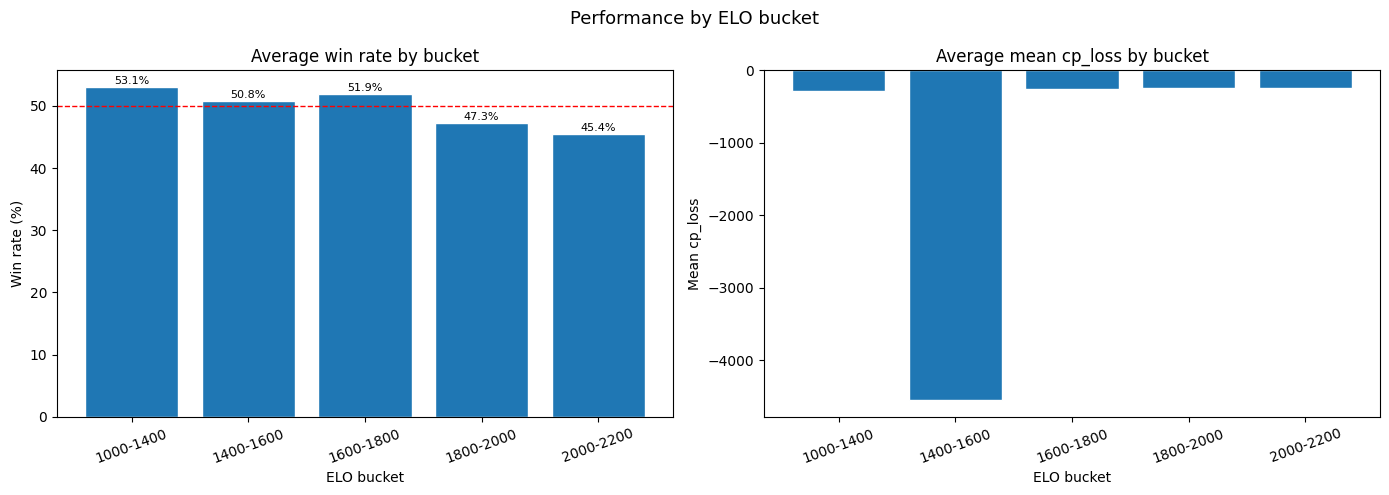

            win_rate  mean_cp_loss  count
elo_bucket                               
1000-1400      0.531      -289.278    197
1400-1600      0.508     -4552.429    191
1600-1800      0.519      -255.871    191
1800-2000      0.473      -248.281    188
2000-2200      0.454      -240.398    174


In [26]:
# 8b. Win rate and mean cp_loss by bucket
bucket_stats = players[players["elo_bucket"] != "manual"].groupby("elo_bucket").agg(
    win_rate     = ("win_rate",    "mean"),
    mean_cp_loss = ("mean_cp_loss", "mean"),
    count        = ("username",    "count"),
).reindex(buckets)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performance by ELO bucket", fontsize=13)

axes[0].bar(bucket_stats.index, bucket_stats["win_rate"] * 100, edgecolor="white")
axes[0].axhline(50, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Average win rate by bucket")
axes[0].set_ylabel("Win rate (%)")
axes[0].set_xlabel("ELO bucket")
plt.sca(axes[0]); plt.xticks(rotation=20)
for i, (_, row) in enumerate(bucket_stats.iterrows()):
    axes[0].text(i, row["win_rate"] * 100 + 0.5, f"{row['win_rate']*100:.1f}%", ha="center", fontsize=8)

axes[1].bar(bucket_stats.index, bucket_stats["mean_cp_loss"], edgecolor="white")
axes[1].set_title("Average mean cp_loss by bucket")
axes[1].set_ylabel("Mean cp_loss")
axes[1].set_xlabel("ELO bucket")
plt.sca(axes[1]); plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

print(bucket_stats.round(3).to_string())

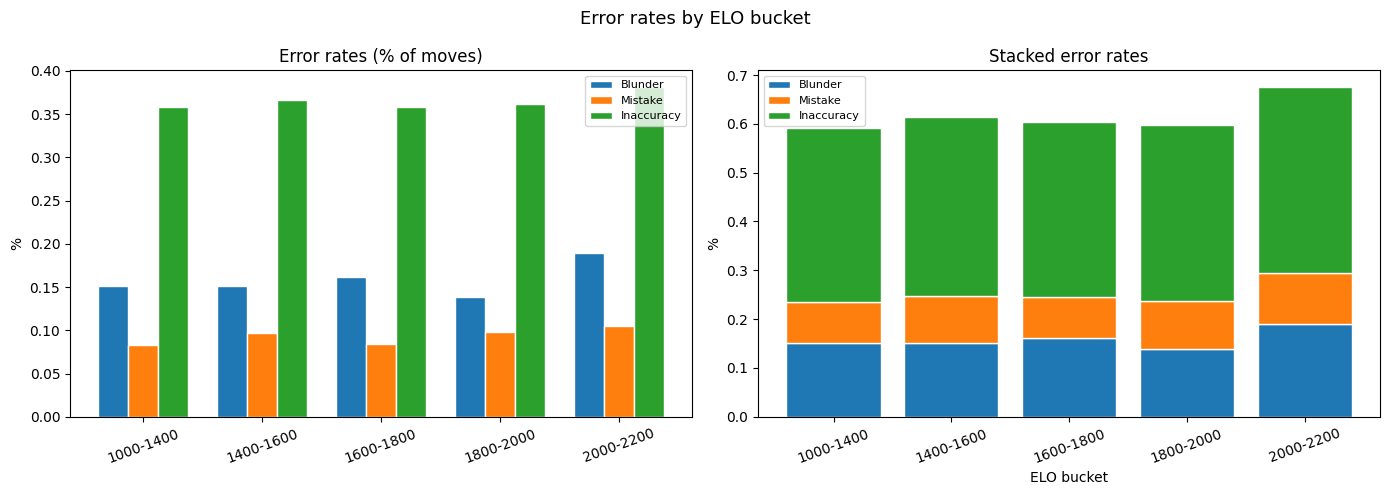

            blunder_rate  mistake_rate  inaccuracy_rate
elo_bucket                                             
1000-1400          0.151         0.084            0.358
1400-1600          0.151         0.096            0.366
1600-1800          0.162         0.084            0.358
1800-2000          0.139         0.098            0.361
2000-2200          0.190         0.104            0.382


In [27]:
# 8c. Blunder / mistake / inaccuracy rates by bucket
error_stats = players[players["elo_bucket"] != "manual"].groupby("elo_bucket").agg(
    blunder_rate    = ("blunder_rate",    "mean"),
    mistake_rate    = ("mistake_rate",    "mean"),
    inaccuracy_rate = ("inaccuracy_rate", "mean"),
).reindex(buckets) * 100  # convert to %

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error rates by ELO bucket", fontsize=13)

# grouped bar
x = np.arange(len(buckets))
w = 0.25
axes[0].bar(x - w, error_stats["blunder_rate"],    width=w, label="Blunder",    edgecolor="white")
axes[0].bar(x,     error_stats["mistake_rate"],    width=w, label="Mistake",    edgecolor="white")
axes[0].bar(x + w, error_stats["inaccuracy_rate"], width=w, label="Inaccuracy", edgecolor="white")
axes[0].set_title("Error rates (% of moves)")
axes[0].set_ylabel("%")
axes[0].set_xticks(x)
axes[0].set_xticklabels(buckets, rotation=20)
axes[0].legend(fontsize=8)

# stacked bar
axes[1].bar(buckets, error_stats["blunder_rate"],    label="Blunder",    edgecolor="white")
axes[1].bar(buckets, error_stats["mistake_rate"],    bottom=error_stats["blunder_rate"], label="Mistake", edgecolor="white")
axes[1].bar(buckets, error_stats["inaccuracy_rate"], bottom=error_stats["blunder_rate"] + error_stats["mistake_rate"], label="Inaccuracy", edgecolor="white")
axes[1].set_title("Stacked error rates")
axes[1].set_ylabel("%")
axes[1].set_xlabel("ELO bucket")
plt.sca(axes[1]); plt.xticks(rotation=20)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(error_stats.round(3).to_string())

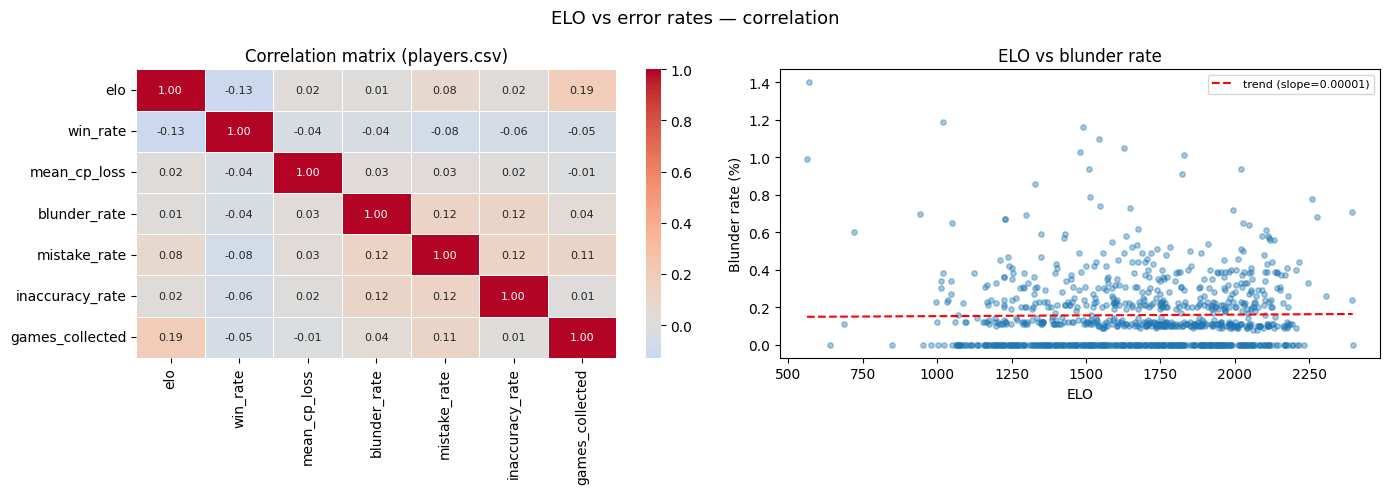

Correlation with ELO:
win_rate          -0.1281
blunder_rate       0.0138
inaccuracy_rate    0.0202
mean_cp_loss       0.0211
mistake_rate       0.0773
games_collected    0.1899


In [28]:
# 8d. Correlation: ELO vs error rates
corr_cols = ["elo", "win_rate", "mean_cp_loss", "blunder_rate", "mistake_rate", "inaccuracy_rate", "games_collected"]
corr_df = players[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ELO vs error rates — correlation", fontsize=13)

# heatmap
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Correlation matrix (players.csv)")

# scatter: ELO vs blunder rate
axes[1].scatter(players["elo"], players["blunder_rate"] * 100, alpha=0.4, s=15)
valid = players[["elo", "blunder_rate"]].dropna()
if len(valid) > 1:
    m, b = np.polyfit(valid["elo"], valid["blunder_rate"] * 100, 1)
    xs = np.linspace(valid["elo"].min(), valid["elo"].max(), 100)
    axes[1].plot(xs, m * xs + b, "r--", linewidth=1.5, label=f"trend (slope={m:.5f})")
axes[1].set_title("ELO vs blunder rate")
axes[1].set_xlabel("ELO")
axes[1].set_ylabel("Blunder rate (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

corr_with_elo = corr_df["elo"].drop("elo").sort_values()
print("Correlation with ELO:")
print(corr_with_elo.round(4).to_string())